## Phase 1: Data Ingestion & Repository Initialization

In [1]:
import os
import requests
import pandas as pd

# 1. Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Directory 'data' created.")

# 2. LAPD Crime Data API Endpoint (Crime from 2020 to Present)
# We use the CSV endpoint for easy pandas integration
DATA_URL = "https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD"
FILE_PATH = "data/lapd_crime_data.csv"

def download_data(url, save_path):
    print("Starting download... this may take a minute as the dataset is large.")
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as f:
            f.write(response.content)
        print(f"Data successfully saved to {save_path}")
    else:
        print(f"Failed to download data. Status code: {response.status_code}")

# Execute the download
if not os.path.exists(FILE_PATH):
    download_data(DATA_URL, FILE_PATH)
else:
    print("Data file already exists. Skipping download.")

# 3. Quick Load to verify
df = pd.read_csv(FILE_PATH)
print(f"Dataset loaded. Total rows: {len(df)}")

Starting download... this may take a minute as the dataset is large.
Data successfully saved to data/lapd_crime_data.csv
Dataset loaded. Total rows: 1004894


### Overview of Actions
In this step, we automated the retrieval of the primary dataset and organized the project environment. This ensures that the workflow is "dynamic"—meaning it doesn't rely on a manually downloaded, static file that could become outdated or lost.

### Key Technical Steps
- Automated Directory Management:
We programmatically created a data/ directory within the root of the Git repository. This keeps the workspace clean by separating raw data files from source code (.py or .ipynb) and documentation.
- API Integration (Socrata Open Data):
Instead of a manual download, we used the Python Requests library to call the Los Angeles Open Data API. This allows the framework to pull the most recent "Crime from 2020 to Present" dataset directly from the City of Los Angeles' servers.
- Local Persistence:
The script streams the data directly into a local CSV file (data/lapd_crime_data.csv). This prevents the need to re-download the massive dataset every time the notebook is restarted, saving bandwidth and time.
- Verification & Validation:
A post-download check was implemented to confirm the file size and structure, ensuring the pandas DataFrame can successfully load the rows before moving to the cleaning phase.

## Phase 2: Data Cleaning & Feature Extraction

In [2]:
import pandas as pd
import numpy as np
import os

# 1. Setup paths
RAW_DATA_PATH = "data/lapd_crime_data.csv"
CLEAN_PATH = "data/lapd_crime_cleaned.csv"
QUALITY_PATH = "data/quality_report.csv"

# Load the data and perform cleaning
if not os.path.exists(RAW_DATA_PATH):
    print("Error: Raw data not found. Please run the Phase 1 downloader first.")
else:
    df = pd.read_csv(RAW_DATA_PATH)
    print(f"Initial Raw Shape: {df.shape}")

    # Step A: Parsing & Basic Cleaning
    df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
    df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
    df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
    df["TIME OCC"] = pd.to_numeric(df["TIME OCC"], errors="coerce")

    # Step B: Time Extraction (Your Logic) 
    # Extract HH and MM from the MILITARY time format (e.g., 2130 -> 21:30)
    df["occ_hour_raw"] = (df["TIME OCC"] // 100)
    df["occ_minute_raw"] = (df["TIME OCC"] % 100)

    # Validate ranges (0-23 hours, 0-59 mins)
    df["occ_hour"] = df["occ_hour_raw"].where(df["occ_hour_raw"].between(0, 23), np.nan)
    df["occ_minute"] = df["occ_minute_raw"].where(df["occ_minute_raw"].between(0, 59), np.nan)

    # Fill invalid hours with 0 (Midnight) to preserve data, then create datetime
    df["occ_hour_filled"] = df["occ_hour"].fillna(0).astype(int)
    df["occ_datetime"] = df["date_occ"] + pd.to_timedelta(df["occ_hour_filled"], unit="h")

    # Step C: Spatial & Temporal Filtering
    before = len(df)
    # Drop rows missing absolute essentials for Spatiotemporal analysis
    df = df.dropna(subset=["date_occ", "LAT", "LON"])
    
    # Remove invalid coordinates (0,0) and points outside realistic boundaries
    df = df[(df["LAT"] != 0) & (df["LON"] != 0)]
    df = df[df["LAT"].between(33, 35) & df["LON"].between(-119, -117)] # LA Specific bounding box
    
    after = len(df)
    print(f"Cleaning: Dropped {before - after} rows. Remaining: {after}")

    # --- Step D: Derivative Features for Research Questions ---
    df["year"] = df["occ_datetime"].dt.year
    df["month"] = df["occ_datetime"].dt.month
    df["day_of_week"] = df["occ_datetime"].dt.day_name()
    df["weekday_num"] = df["occ_datetime"].dt.weekday  # Mon=0
    df["is_weekend"] = df["weekday_num"].isin([5, 6]).astype(int)

    # Time Buckets for Diagnostic Analysis
    def get_time_bucket(hour):
        if 0 <= hour <= 5: return "Night"
        elif 6 <= hour <= 11: return "Morning"
        elif 12 <= hour <= 17: return "Afternoon"
        else: return "Evening"
    
    df["time_bucket"] = df["occ_hour_filled"].apply(get_time_bucket)

    # Step E: Quality Report & Saving
    quality = pd.DataFrame({
        "column": df.columns,
        "nulls": [df[c].isna().sum() for c in df.columns],
        "null_pct": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
        "dtype": [str(df[c].dtype) for c in df.columns]
    }).sort_values("null_pct", ascending=False)

    # SAVE TO NEW FILE
    df.to_csv(CLEAN_PATH, index=False)
    quality.to_csv(QUALITY_PATH, index=False)
    
    print(f"SUCCESS: Cleaned data saved to {CLEAN_PATH}")

Initial Raw Shape: (1004894, 28)


C:\Users\aryam\AppData\Local\Temp\ipykernel_13600\253037543.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")


Cleaning: Dropped 2240 rows. Remaining: 1002654
SUCCESS: Cleaned data saved to data/lapd_crime_cleaned.csv


## Phase 3: Diagnostic Analysis

#### Crime Categorization - Diagnostic Setup

In [3]:
# 1. Define the mapping logic based on standard FBI/UCR definitions
violent_keywords = [
    'HOMICIDE', 'ROBBERY', 'ASSAULT', 'BATTERY', 'KIDNAPPING', 
    'RAPE', 'MANSLAUGHTER', 'SHOTS FIRED'
]

property_keywords = [
    'BURGLARY', 'THEFT', 'STOLEN', 'VANDALISM', 'FRAUD', 
    'FORGERY', 'EMBEZZLEMENT', 'SHOPLIFTING', 'BIKE'
]

def categorize_crime(desc):
    desc = str(desc).upper()
    if any(word in desc for word in violent_keywords):
        return 'Violent'
    elif any(word in desc for word in property_keywords):
        return 'Property'
    else:
        return 'Other/Administrative'

# 2. Apply the mapping to the cleaned dataset
df['crime_type'] = df['Crm Cd Desc'].apply(categorize_crime)

# 3. Quick verification of the distribution
print("Crime Category Distribution")
print(df['crime_type'].value_counts(normalize=True) * 100)

# 4. Save the updated dataset
df.to_csv('data/lapd_crime_cleaned.csv', index=False)

Crime Category Distribution
crime_type
Property                62.923700
Violent                 25.152545
Other/Administrative    11.923754
Name: proportion, dtype: float64


#### Temporal Heatmaps

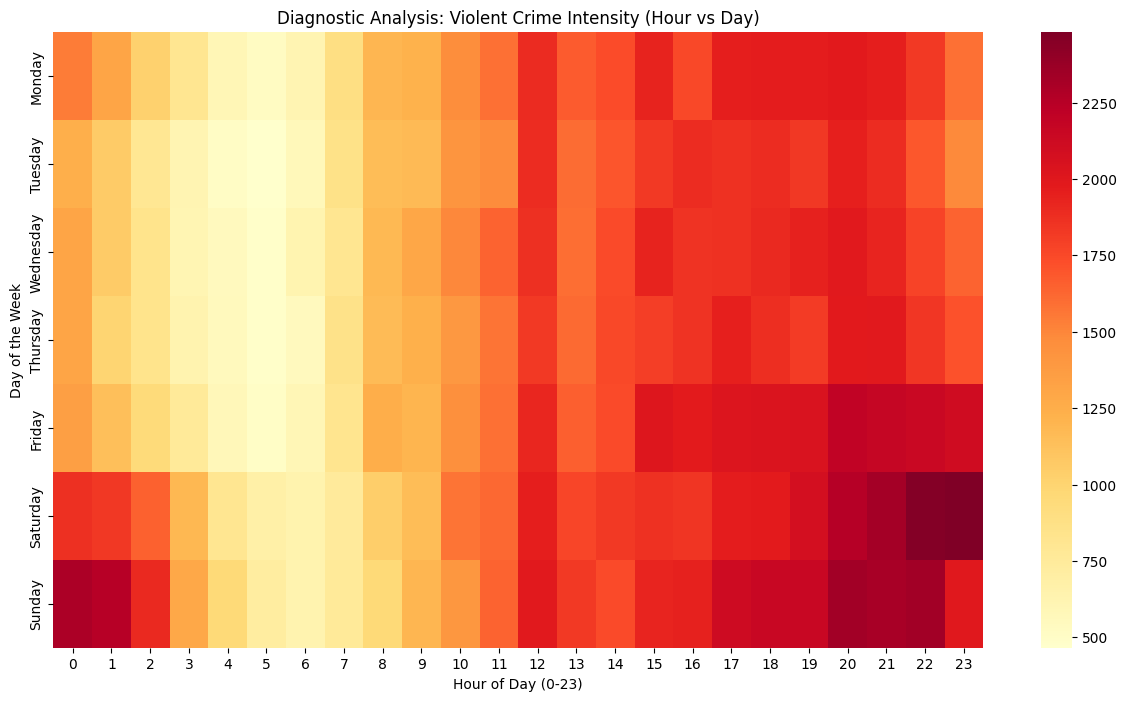

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a Pivot Table for the Heatmap (Hourly vs Weekly)
# We'll do this for Violent Crimes first
violent_df = df[df['crime_type'] == 'Violent']
temporal_pivot = violent_df.groupby(['day_of_week', 'occ_hour_filled']).size().unstack()

# Reorder days to be logical (Monday-Sunday)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temporal_pivot = temporal_pivot.reindex(days)

# 2. Plotting
plt.figure(figsize=(15, 8))
sns.heatmap(temporal_pivot, cmap='YlOrRd', annot=False)
plt.title('Diagnostic Analysis: Violent Crime Intensity (Hour vs Day)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of the Week')
plt.show()

#### Premise Categorization (Commercial vs. Residential)

In [5]:
# 1. Define keyword lists for categorization
commercial_keywords = ['STORE', 'MARKET', 'RESTAURANT', 'BANK', 'OFFICE', 'MALL', 'GAS STATION', 'HOTEL', 'BAR', 'CLUB']
residential_arguments = ['SINGLE FAMILY DWELLING', 'MULTI-UNIT DWELLING', 'APARTMENT', 'CONDO', 'RESIDENCE', 'DRIVEWAY']

def categorize_premise(desc):
    desc = str(desc).upper()
    if any(word in desc for word in residential_arguments):
        return 'Residential'
    elif any(word in desc for word in commercial_keywords):
        return 'Commercial'
    else:
        return 'Public/Other'

# 2. Apply categorization
df['env_type'] = df['Premis Desc'].apply(categorize_premise)

# 3. Quick check of the new Diagnostic variable
print("Premise Environment Distribution")
print(df['env_type'].value_counts(normalize=True) * 100)

Premise Environment Distribution
env_type
Public/Other    60.492653
Residential     30.814419
Commercial       8.692929
Name: proportion, dtype: float64


#### Diagnostic Matrix (Time vs. Environment)

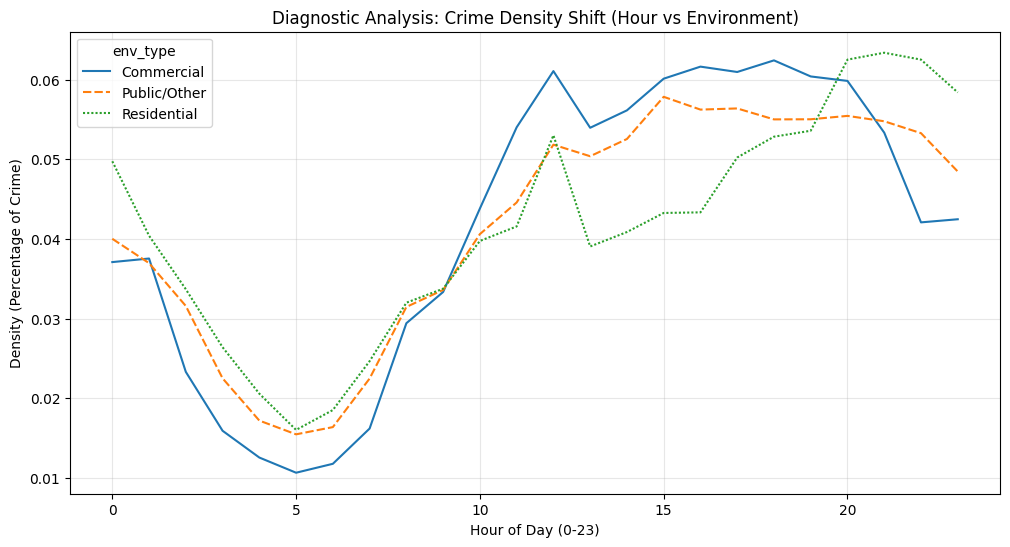

In [6]:
# Create a density matrix of Hour vs Environment Type for Violent Crimes
violent_df = df[df['crime_type'] == 'Violent']
env_time_matrix = pd.crosstab(violent_df['occ_hour_filled'], violent_df['env_type'], normalize='columns')

# Plotting the shift
plt.figure(figsize=(12, 6))
sns.lineplot(data=env_time_matrix)
plt.title('Diagnostic Analysis: Crime Density Shift (Hour vs Environment)')
plt.ylabel('Density (Percentage of Crime)')
plt.xlabel('Hour of Day (0-23)')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
df.to_csv('data/lapd_crime_cleaned.csv', index=False)
print("Diagnostic categories (env_type) saved to cleaned dataset.")

Diagnostic categories (env_type) saved to cleaned dataset.


#### Calculating and Mapping the Hourly Mean Center

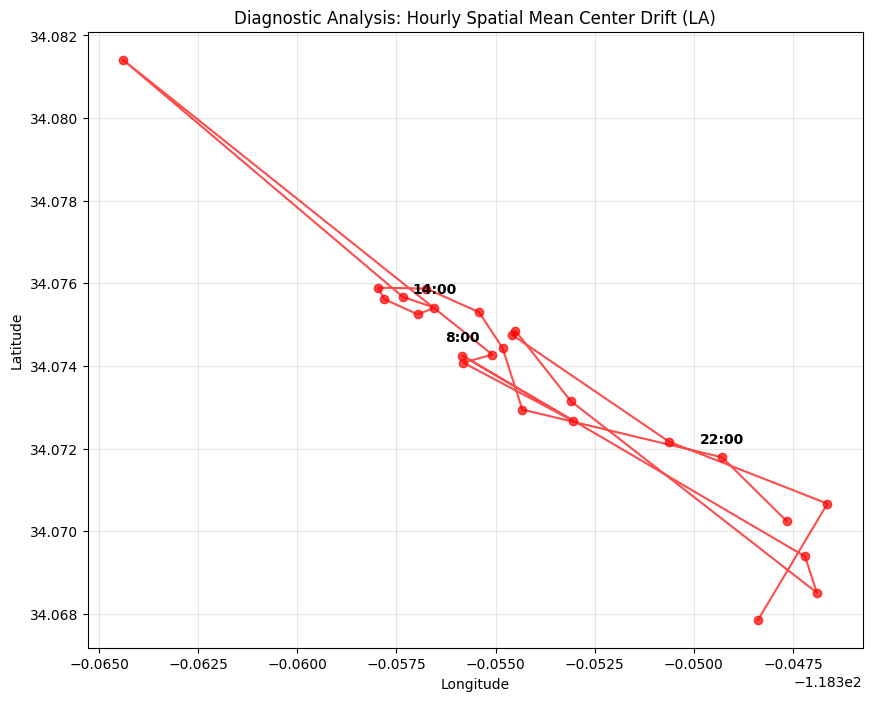

In [8]:
import matplotlib.pyplot as plt

# 1. Calculate the Mean Center for each hour
hourly_centers = df.groupby('occ_hour_filled')[['LAT', 'LON']].mean().reset_index()

# 2. Plot the 'Drift' Path
plt.figure(figsize=(10, 8))
plt.plot(hourly_centers['LON'], hourly_centers['LAT'], marker='o', linestyle='-', color='red', alpha=0.7)

# 3. Label specific hours (e.g., 8 AM, 2 PM, 10 PM) to show the shift
for i, row in hourly_centers.iterrows():
    if row['occ_hour_filled'] in [8, 14, 22]:
        plt.annotate(f"{int(row['occ_hour_filled'])}:00", (row['LON'], row['LAT']), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('Diagnostic Analysis: Hourly Spatial Mean Center Drift (LA)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

#### Statistical Density & Significance

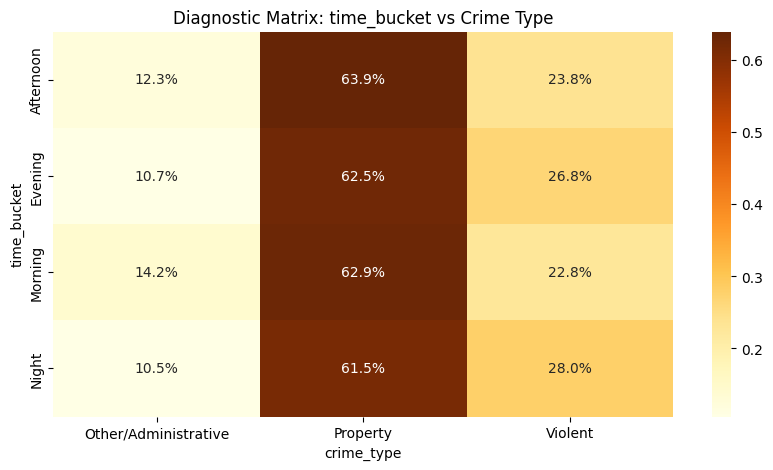

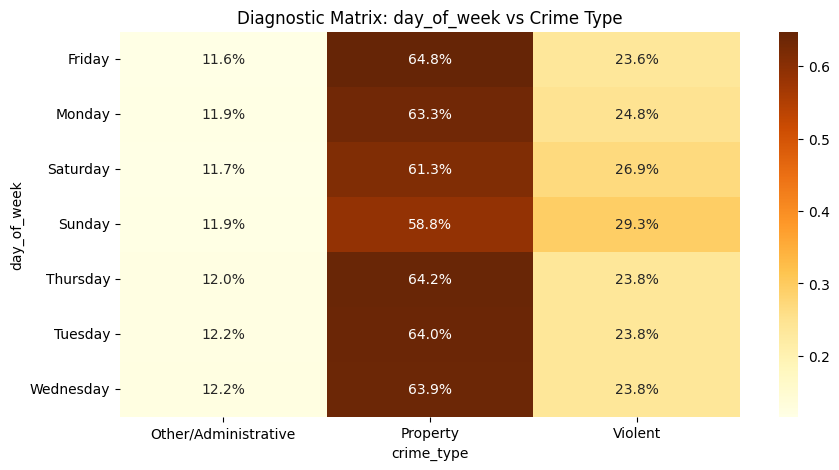

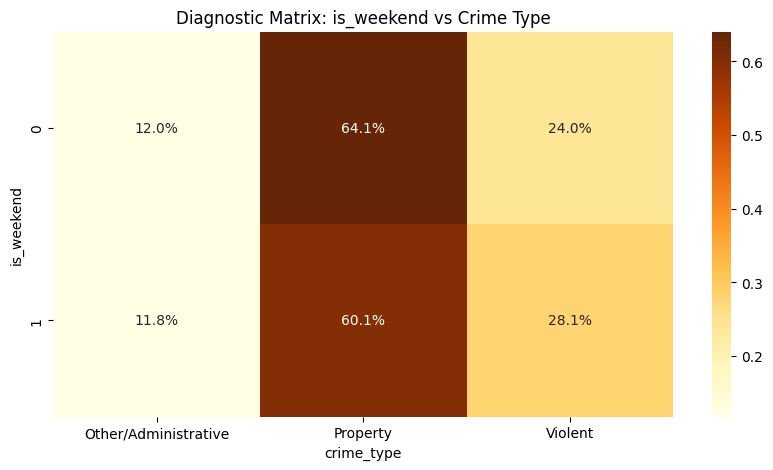

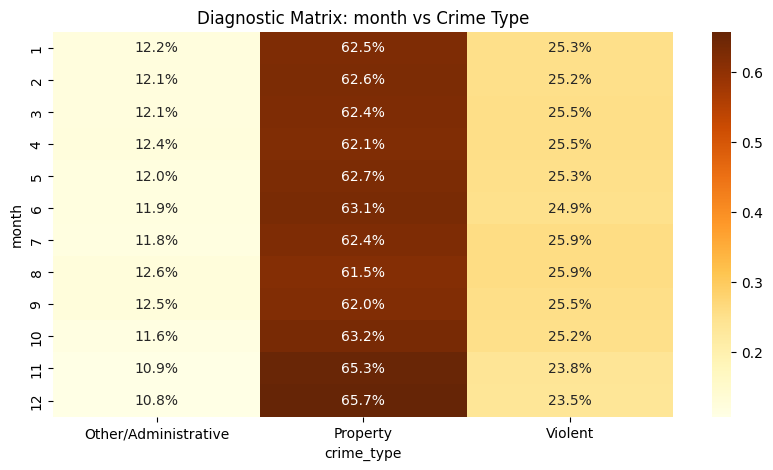

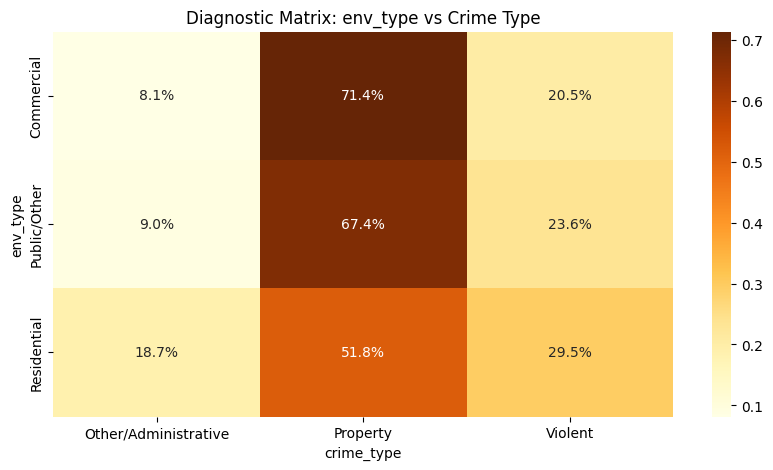

       Feature  Chi-Square        P-Value  Significant
0  time_bucket     3253.27   0.000000e+00         True
1  day_of_week     2252.60   0.000000e+00         True
2   is_weekend     1902.51   0.000000e+00         True
3        month      662.12  7.497224e-126         True
4     env_type    30046.62   0.000000e+00         True


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv('data/lapd_crime_cleaned.csv')

test_columns = ['time_bucket', 'day_of_week', 'is_weekend', 'month', 'env_type']
diagnostic_results = []

for col in test_columns:
    contingency_table = pd.crosstab(df[col], df['crime_type'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    diagnostic_results.append({
        'Feature': col,
        'Chi-Square': round(chi2, 2),
        'P-Value': p,
        'Significant': p < 0.05
    })
    
    plt.figure(figsize=(10, 5))
    density_plot = pd.crosstab(df[col], df['crime_type'], normalize='index')
    sns.heatmap(density_plot, annot=True, cmap='YlOrBr', fmt='.1%')
    plt.title(f'Diagnostic Matrix: {col} vs Crime Type')
    plt.show()

results_df = pd.DataFrame(diagnostic_results)
print(results_df)

## Phase 4: Clustering 

#### Determining "K" with the Elbow Method

C:\Users\aryam\AppData\Local\Temp\ipykernel_13600\3697949182.py:31: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2-p1, p1-p3)) / np.linalg.norm(p2-p1)


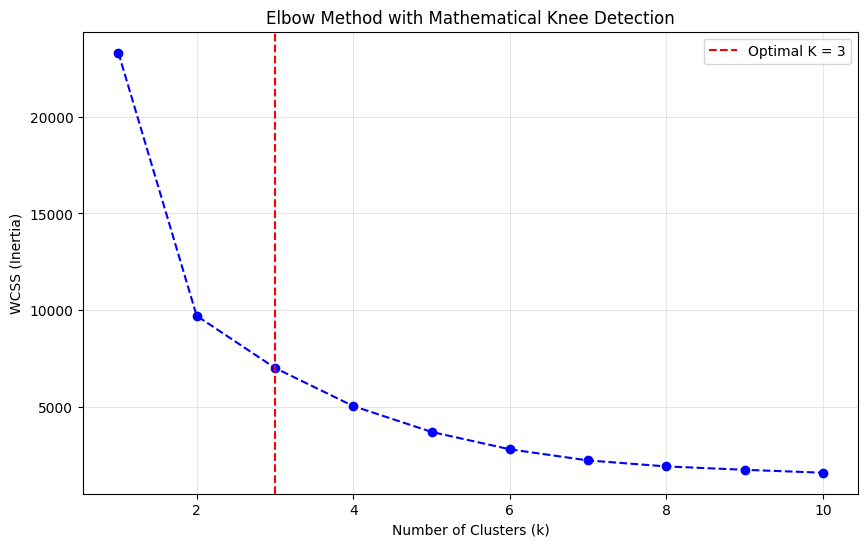

The statistically optimal value for k is: 3


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('data/lapd_crime_cleaned.csv')
coords = df[['LAT', 'LON']]

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(coords)
    wcss.append(kmeans.inertia_)

# --- Statistical Calculation of the "Knee" point ---
# We find the point furthest from the line connecting the first (k=1) and last (k=10) points
def find_knee_point(x, y):
    x = np.array(x)
    y = np.array(y)
    
    # Line between first and last points
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    
    distances = []
    for i in range(len(x)):
        p3 = np.array([x[i], y[i]])
        # Distance from point p3 to line p1-p2
        d = np.abs(np.cross(p2-p1, p1-p3)) / np.linalg.norm(p2-p1)
        distances.append(d)
        
    return x[np.argmax(distances)]

optimal_k = find_knee_point(list(k_range), wcss)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.title('Elbow Method with Mathematical Knee Detection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The statistically optimal value for k is: {optimal_k}")

#### Creating the Risk-Tiered K-Means Zones

#### Pinpointing "Bullseye" Hotspots

#### Dual Spatial Mapping (Strategic vs. Tactical)

## Phase 5 : Baseline Competition